# Customer churn - analysis walkthrough

This notebook is the narrative version of the analysis. Every function it calls lives in `src/`,
so the notebook and the production training job run *the same code* - there is no notebook-only
logic that quietly differs from what gets deployed.

Order of business:

1. Churn definition and how the data was generated
2. Data quality and exploratory analysis
3. Feature engineering rationale
4. Model comparison and selection
5. Evaluation, threshold choice and business framing
6. Explainability

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, eda, evaluate, explain
from src.data_prep import FeatureEngineer, RowCleaner, load_raw, prepare_dataset
from src.data_generation import generate_dataset

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

## 1. Churn definition

> **A customer is churned if they place no order in the 90 days following the snapshot date
> (2026-01-01).**

Three things this definition buys us, and one it costs:

- It is **observable**. Nobody in e-commerce cancels a subscription to signal they are leaving;
  they just stop coming back. Absence of purchase is the only reliable signal.
- It is **forward-looking**. Features come from behaviour *before* the snapshot, the label from
  *after* it. There is no way for the label to leak into a feature by construction.
- It is **actionable**. 90 days is long enough to be meaningful and short enough that a retention
  offer can still land in time.

The cost: it is a *proxy*. A customer who buys twice a year is labelled churned every time we look
at them, despite being a perfectly healthy customer. That miscalibration for low-frequency
shoppers is a real limitation, and it is why the engineered feature `recency_vs_habit` (silence
relative to that customer's own rhythm) matters more than raw recency.

In [2]:
df = load_raw()
print(f"{len(df):,} rows, {df[config.ID_COLUMN].nunique():,} unique customers")
print(f"Churn rate: {df[config.TARGET].mean():.1%}")
df.head(3)

12,300 rows, 12,000 unique customers
Churn rate: 27.0%


,customer_id,age,tenure_months,orders,orders_last_90d,average_order_value,order_value_std,days_since_last_order,support_tickets,support_tickets_last_180d,returns,discount_order_share,newsletter_opens_last_90d,subscription_type,country,acquisition_channel,primary_device,snapshot_date,orders_in_outcome_window,churned,subscription_cancelled_at_export
0,CUST-003456,42.0,31.2,42,5,79.08,40.85,74.0,2.0,0,2,0.126,3,BASIC,UK,paid_search,mobile,2026-01-01,3,0,0
1,CUST-008064,47.0,13.4,14,0,40.72,21.75,114.0,6.0,4,1,0.364,6,free,DE,paid_search,mobile,2026-01-01,0,1,1
2,CUST-011616,32.0,30.0,15,4,47.58,13.50,55.0,6.0,4,3,0.077,1,basic,Spain,paid_search,mobile,2026-01-01,2,0,0


### How the data was generated

Synthetic, but not synthetic in the lazy way. Rather than inventing feature columns and then
writing the label as a rule over them (which makes any model look brilliant and proves nothing),
`src/data_generation.py` simulates the underlying behaviour:

1. Each customer gets a latent purchase rate and a latent *dormancy time* drawn from a hazard
   model driven by support friction, discount dependence, return rate, tier and acquisition channel.
2. Orders are a Poisson process, active only until the dormancy time.
3. Features are read off the orders before the snapshot; the label is read off the orders after it.

The result is a dataset where recency is informative but not deterministic - the same irreducible
noise a real churn problem has. It is also why the ROC-AUC ceiling here is around 0.91 rather
than 0.99.

In [3]:
issues = eda.find_issues(df)
for i, issue in enumerate(issues, 1):
    print(f"{i}. {issue}\n")

1. **Duplicate customer rows**: 300 repeated `customer_id` values (re-run of the export job). Fix: `drop_duplicates(subset='customer_id')` before splitting, so the same customer cannot land in both train and test.

2. **Age**: 859 missing (7.0%) and 25 impossible values (0, 3, 129, 214). Fix: impossible -> NaN, then median imputation plus a `missingindicator_age` column, because self-reported age is missing non-randomly.

3. **Sentinel values**: `days_since_last_order == -1` on 463 rows means 'never ordered', not '-1 days'. Fix: convert to NaN and add an explicit `never_ordered` flag - leaving -1 in place would tell the model these are the *most recent* buyers.

4. **Unit inconsistency**: 37 `average_order_value` rows are ~100x the rest (exported in cents). Fix: divide values above 1500 by 100.

5. **Inconsistent categories**: 13 raw `country` spellings ('UK', 'uk', 'GB', 'United Kingdom ') collapsing to ~10 real countries; `subscription_type` arrives in mixed case. Fix: canonicalise i

## 2. Data quality

Every defect above was injected deliberately, and each one has a distinct failure mode if ignored.
The most dangerous is the `-1` sentinel in `days_since_last_order`: it is a legacy ETL convention
for "never ordered", but numerically it reads as *the most recent buyer in the dataset*. Left
untouched, the model learns that never-ordering customers are the safest ones.

The second most dangerous is `subscription_cancelled_at_export`, which is not a data-quality
problem at all but a **leak** - see section 4.

In [4]:
quality = eda.quality_report(df)
quality[quality["missing_pct"] > 0]

,column,dtype,missing_pct,n_unique,min,median,max
1,age,float64,6.98,69,0.0,38.0,214.0
5,average_order_value,float64,3.76,5969,11.75,51.95,10152.0
6,order_value_std,float64,3.76,3361,0.0,15.8,104.28
8,support_tickets,float64,3.04,34,0.0,1.0,50.0
11,discount_order_share,float64,3.76,792,0.0,0.264,0.972


In [5]:
cleaned = RowCleaner().fit_transform(df)
comparison = pd.DataFrame({
    "raw_country_values": [df["country"].nunique()],
    "cleaned_country_values": [cleaned["country"].nunique()],
    "raw_max_aov": [df["average_order_value"].max()],
    "cleaned_max_aov": [cleaned["average_order_value"].max()],
    "raw_min_recency": [df["days_since_last_order"].min()],
    "cleaned_min_recency": [cleaned["days_since_last_order"].min()],
    "never_ordered_flagged": [int(cleaned["never_ordered"].sum())],
})
comparison.T.rename(columns={0: "value"})

,value
raw_country_values,13.00
cleaned_country_values,7.00
raw_max_aov,10152.00
cleaned_max_aov,262.98
raw_min_recency,-1.00
cleaned_min_recency,0.00
never_ordered_flagged,463.00


## 3. Relationship with churn, and feature engineering

The table below shows the churn rate in the bottom vs top quintile of each numeric feature.

In [6]:
eda.target_relationships(df)

,feature,churn_rate_lowest_quintile,churn_rate_highest_quintile,spread,point_biserial_corr
0,days_since_last_order,0.055,0.790,0.735,0.614
1,orders_last_90d,0.534,0.020,-0.514,-0.395
2,orders,0.483,0.079,-0.404,-0.238
3,tenure_months,0.166,0.365,0.199,0.168
4,returns,0.327,0.134,-0.194,-0.142
5,support_tickets,0.221,0.403,0.183,0.179
6,order_value_std,0.322,0.226,-0.096,-0.076
7,support_tickets_last_180d,0.253,0.347,0.094,0.095
8,average_order_value,0.287,0.209,-0.078,-0.062
9,discount_order_share,0.225,0.285,0.059,0.050


### Why ratios beat raw counts

`orders = 10` means something entirely different for a 2-month-old account and a 3-year-old one.
Every engineered feature normalises a count by the exposure that produced it:

| Feature | Definition | Why |
|---|---|---|
| `orders_per_month` | orders / tenure | Purchase intensity, free of tenure confounding |
| `expected_order_gap_days` | tenure days / orders | That customer's personal buying rhythm |
| `recency_vs_habit` | recency / expected gap | **The key feature.** 40 days of silence is alarming for a weekly buyer, normal for a twice-a-year buyer |
| `recent_order_share` | orders in 90d / lifetime orders | Are they accelerating or fading? |
| `support_tickets_per_order` | tickets / orders | Friction per unit of value delivered |
| `return_rate` | returns / orders | Dissatisfaction proxy |
| `order_value_cv` | order value std / mean | Erratic vs habitual spending |

One feature was tried and **removed**: `log_days_since_last_order`. It was collinear with raw
recency, added nothing measurable (CV PR-AUC 0.8391 with it, 0.8387 without), and took a *negative* coefficient
that made "days since last order" read as risk-reducing in the explanation table. A feature that
buys no accuracy and costs interpretability is a net loss.

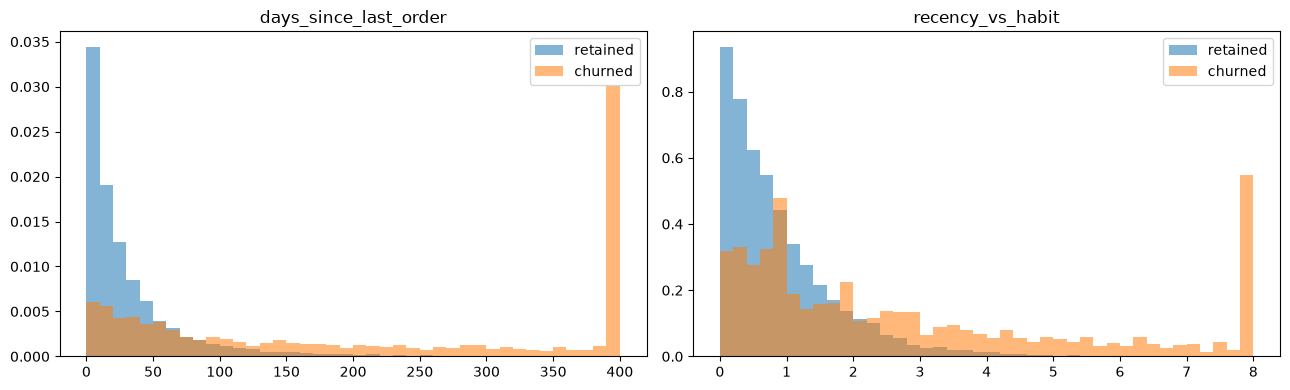

In [7]:
engineered = FeatureEngineer().fit_transform(cleaned)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, cap in [(axes[0], "days_since_last_order", 400), (axes[1], "recency_vs_habit", 8)]:
    for label in (0, 1):
        ax.hist(engineered.loc[df[config.TARGET] == label, col].clip(upper=cap).dropna(),
                bins=40, alpha=0.55, density=True, label="churned" if label else "retained")
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

## 4. Validation strategy and data leakage

```
raw extract
  |-- de-duplicate on customer_id, drop leaky columns
  |-- stratified 80/20 split -> TEST (sealed)
        |
        +-- TRAIN
              |-- 5-fold stratified CV -> hyperparameter search
              |-- out-of-fold predictions -> model selection AND threshold choice
              |-- refit best config on all of TRAIN
  |-- score TEST exactly once
```

Four specific leakage risks and what was done about each:

1. **Target leakage from a future column.** `subscription_cancelled_at_export` is written when the
   CRM extract is taken - after the outcome window has closed. Dropped via `config.LEAKY_COLUMNS`.
   The cell below quantifies what keeping it would have "bought".
2. **Preprocessing leakage.** Imputer medians and scaler statistics are fitted inside each CV fold
   because every step lives in one `Pipeline`. Fitting them on the full dataset first is the most
   common silent leak in tutorial code.
3. **Duplicate rows across the split.** The extract contains 300 duplicated customers; without
   de-duplication before splitting, the same customer appears in both train and test.
4. **Test-set contamination through tuning.** The threshold is as much a hyperparameter as `C` is,
   so it is chosen on out-of-fold predictions, never on the test set.

In [8]:
import json
report = json.loads((config.REPORT_DIR / "evaluation.json").read_text())
leak = report["leakage_demonstration"]
print(f"CV PR-AUC WITH the leaky column:    {leak['cv_pr_auc_with_leak']:.4f}")
print(f"CV PR-AUC of the honest model:      {report['leaderboard_cv'][0]['cv_pr_auc']:.4f}")
print("\nThe leaky model looks better and is worthless: at scoring time that column is empty")
print("for exactly the customers we are trying to predict.")

CV PR-AUC WITH the leaky column:    0.9581
CV PR-AUC of the honest model:      0.8407

The leaky model looks better and is worthless: at scoring time that column is empty
for exactly the customers we are trying to predict.


## 5. Model comparison

Four candidates, spanning the complexity range.

In [9]:
pd.DataFrame(report["leaderboard_cv"])[["model", "family", "cv_pr_auc", "cv_pr_auc_std", "cv_roc_auc"]]

,model,family,cv_pr_auc,cv_pr_auc_std,cv_roc_auc
0,gradient_boosting,tree_ensemble,0.840739,0.012668,0.901462
1,logistic_regression,linear,0.838879,0.013415,0.900870
2,recency_rule_baseline,baseline,0.775475,0.017231,0.859691
3,majority_baseline,baseline,0.271250,0.000208,0.500000


### Choosing between them

Gradient boosting wins on raw CV PR-AUC (0.8407 vs 0.8389) - by **0.0018, against a fold standard
deviation of 0.013**. That is noise, not a difference.

The **one-standard-error rule** therefore selects logistic regression: when models are
statistically tied, take the simpler one. Concretely that buys:

- coefficients a stakeholder can read directly as odds ratios;
- exact per-customer explanations with no SHAP dependency at serving time;
- sub-millisecond inference and a small artefact;
- fewer ways to fail silently on retraining.

If the boosted model had won by, say, 0.03 PR-AUC, the trade would go the other way - the rule is
a tie-breaker, not a preference for simplicity at any cost. The test at
`tests/test_pipeline.py::test_one_standard_error_rule_still_picks_a_clearly_better_model` pins that
behaviour.

## 6. Evaluation

### Why not accuracy

The majority-class baseline achieves **72.9% accuracy** on the test set while catching *zero*
churners. Any metric that rewards that is the wrong metric.

### Metric priority for this problem

**Recall first, subject to a precision floor**, with **PR-AUC** as the headline ranking metric.

The reasoning is a cost asymmetry: a retention offer costs about £8, and a churned customer costs
about £120 in forward margin (of which an offer recovers ~30%). Missing a churner is roughly 15x
more expensive than bothering a loyal customer. PR-AUC rather than ROC-AUC because we care about
the ranking of the *positive* class, and ROC-AUC is optimistic under class imbalance.

### Class imbalance is handled at the threshold, not in the loss

`class_weight="balanced"` was tried and rejected. Reweighting the loss and lowering the threshold
express the same preference, so doing both double-counts it. On out-of-fold predictions weighting
left ranking untouched (PR-AUC 0.8386 vs 0.8388) while pushing the mean predicted probability to
0.387 against a 0.271 base rate (Brier 0.119 vs 0.097). Unweighted, the probabilities are honest
and the cost asymmetry is applied once, where its assumptions are written down.

In [10]:
test = report["test_metrics"]
base = report["baseline_test_metrics"]
pd.DataFrame({
    "majority baseline": base["majority_baseline"],
    "recency rule (incumbent)": base["recency_rule_baseline"],
    "logistic regression (selected)": test,
}).T[["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "brier",
      "expected_cost_per_customer", "lift_at_10pct"]].round(3)

,accuracy,precision,recall,f1,roc_auc,pr_auc,brier,expected_cost_per_customer,lift_at_10pct
majority baseline,0.729,0.000,0.000,0.000,0.500,0.271,0.198,32.550,1.045
recency rule (incumbent),0.814,0.628,0.771,0.692,0.874,0.795,0.148,27.683,3.594
logistic regression (selected),0.815,0.618,0.839,0.711,0.911,0.851,0.093,27.307,3.671


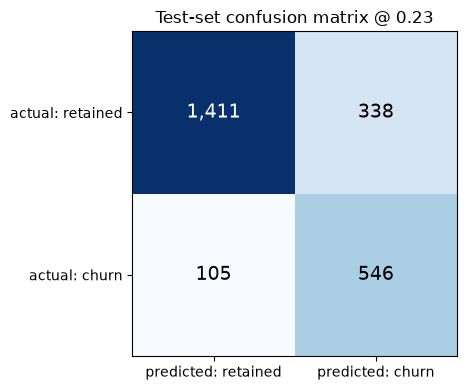

Of 651 real churners we catch 546 (83.9%).
Of 884 customers we flag, 546 really churn (61.8%).


In [11]:
cm = np.array([[test["tn"], test["fp"]], [test["fn"], test["tp"]]])
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=14,
            color="white" if v > cm.max() / 2 else "black")
ax.set_xticks([0, 1], ["predicted: retained", "predicted: churn"])
ax.set_yticks([0, 1], ["actual: retained", "actual: churn"])
ax.set_title(f"Test-set confusion matrix @ {test['threshold']}")
plt.tight_layout(); plt.show()

print(f"Of {test['tp'] + test['fn']} real churners we catch {test['tp']} ({test['recall']:.1%}).")
print(f"Of {test['tp'] + test['fp']} customers we flag, {test['tp']} really churn ({test['precision']:.1%}).")

### The threshold is a business decision, not a modelling one

0.5 is an arbitrary default. The threshold was chosen by sweeping it on out-of-fold validation
predictions and minimising expected cost under the stated assumptions - which lands at **0.23**,
well below 0.5, exactly as the 15:1 cost asymmetry implies.

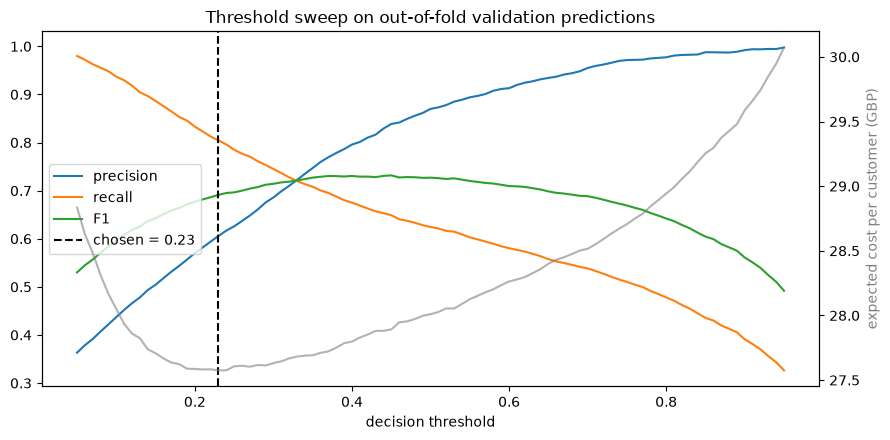

In [12]:
sweep = pd.DataFrame(report["threshold_sweep"])
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(sweep["threshold"], sweep["precision"], label="precision")
ax1.plot(sweep["threshold"], sweep["recall"], label="recall")
ax1.plot(sweep["threshold"], sweep["f1"], label="F1")
ax1.axvline(test["threshold"], ls="--", color="black", label=f"chosen = {test['threshold']}")
ax1.set_xlabel("decision threshold"); ax1.legend(loc="center left")
ax2 = ax1.twinx()
ax2.plot(sweep["threshold"], sweep["cost"], color="grey", alpha=0.6)
ax2.set_ylabel("expected cost per customer (GBP)", color="grey")
plt.title("Threshold sweep on out-of-fold validation predictions")
plt.tight_layout(); plt.show()

### Honest comparison against the incumbent rule

The recency rule the business already uses reaches PR-AUC 0.795; the model reaches 0.850. At the
operating point the model catches **44 more churners** (546 vs 502) at the cost of **41 more false
alarms** (338 vs 297).

Under the cost assumptions that is worth roughly **£0.38 per customer per quarter** - about £45k a
year on a 30,000-customer base. Real, but not spectacular, and worth saying plainly: most of the
signal in churn prediction is recency, and a good model's job is to add the part recency misses -
customers whose *personal* cadence has broken even though their absolute recency looks fine.

## 7. Explainability

Permutation importance measures how much held-out PR-AUC is lost when a column is shuffled. It is
computed on the raw input columns, so each row is something the business can act on rather than a
one-hot fragment.

In [13]:
pd.DataFrame(report["permutation_importance"])[["label", "importance_mean", "importance_std"]].round(4)

,label,importance_mean,importance_std
0,Days since last order,0.4524,0.0063
1,Lifetime orders,0.1373,0.0077
2,Orders in the last 90 days,0.0878,0.0069
3,Account tenure,0.0686,0.0076
4,Lifetime returns,0.0087,0.0046
5,Variability of order values,0.0054,0.0009
6,Average order value,0.0042,0.0013
7,Lifetime support tickets,0.0008,0.0007
8,subscription type,0.0007,0.0002
9,How the customer was acquired,0.0005,0.0003


In [14]:
coef = pd.DataFrame(report["logistic_coefficients"])
coef[coef["coefficient"].abs() > 0.05][["label", "coefficient", "odds_ratio"]].round(3)

,label,coefficient,odds_ratio
0,Silence relative to their own normal buying rh...,1.185,3.272
1,Orders in the last 90 days,-1.164,0.312
2,Typical gap between orders,0.886,2.425
3,Days since last order,0.668,1.950
4,Order frequency,-0.633,0.531
5,acquisition channel referral,-0.135,0.874
6,Basic-tier account,-0.126,0.882
7,Order-value consistency,0.126,1.134
8,Share of lifetime orders placed in the last 90...,-0.113,0.893
9,Lifetime support tickets,0.097,1.101


### What this says to a non-technical stakeholder

(Features are standardised before fitting, so each odds ratio is the effect of a **one-standard-deviation** change in that feature, not of one unit.)

> **The model mostly measures one thing: has this customer gone quiet relative to their own normal
> pattern?**
>
> - **Going quiet relative to your own rhythm is the strongest driver.** A one-standard-deviation
>   increase in silence-versus-habit multiplies the odds of churning by about **3.3x**.
> - **Recent buying protects.** A standard deviation more orders in the last 90 days cuts the odds
>   of churning by about **70%**.
> - Customers with a slow natural rhythm are riskier overall - they have less habit holding them.
> - Support tickets and returns push risk up, but weakly. They are a symptom, not the main story.
>
> **What it can and cannot do.** Out of every 100 customers it flags, about 62 would really have
> churned; it catches roughly 84 of every 100 churners. So the flag list is worth acting on, and it
> is not a certainty about any individual - treat it as a prioritised call list, not a verdict.
>
> **The main limitation.** The model has never seen a retention campaign. Once we start acting on
> its output, its own predictions change the outcomes it is later measured against, and its
> accuracy will appear to fall. Keeping a small untreated control group is what makes it possible
> to keep measuring honestly.

## 8. Limitations

1. **The data is synthetic.** Model performance on real data will differ; the *methodology* is
   what transfers.
2. **90 days of silence is a proxy for churn**, and it mislabels genuinely slow-cadence customers.
3. **A single snapshot.** A production system should train on multiple snapshot dates and validate
   forward in time, so seasonality is represented and the split is temporal rather than random.
4. **No intervention data**, so this predicts churn rather than *save-ability*. Uplift modelling is
   the right next step, and it needs a randomised holdout in place first.
5. **Calibration is good** (Brier 0.093, reliability curve on the diagonal) - but measured on
   synthetic data from a stationary process. On real, drifting data it must be re-checked at every
   retrain before customer-level probabilities are quoted in a financial forecast.